In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

# 1. Data Collection

In [4]:
now = datetime.now()

start = datetime(now.year-10, now.month, now.day)
end = now
ticker = "AAPL"
df = yf.download(ticker, start, end, auto_adjust=False)

df.columns = df.columns.get_level_values(0)
df.columns.name = None                       
df.index.name = "Date" 
df

[*********************100%***********************]  1 of 1 completed


,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-03-28,23.823477,26.297501,26.547501,26.264999,26.500000,77645600
2016-03-29,24.387407,26.920000,26.947500,26.219999,26.222500,124760400
2016-03-30,24.813208,27.389999,27.605000,27.150000,27.162500,182404400
2016-03-31,24.684101,27.247499,27.475000,27.219999,27.430000,103553600
2016-04-01,24.910589,27.497499,27.500000,27.049999,27.195000,103496000
...,...,...,...,...,...,...
2026-03-20,247.990005,247.990005,249.199997,246.000000,247.979996,88331100
2026-03-23,251.490005,251.490005,254.600006,250.279999,253.970001,40546100
2026-03-24,251.639999,251.639999,254.830002,249.550003,250.350006,45152300


In [5]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-03-28,23.823477,26.297501,26.547501,26.264999,26.5000,77645600
2016-03-29,24.387407,26.920000,26.947500,26.219999,26.2225,124760400
2016-03-30,24.813208,27.389999,27.605000,27.150000,27.1625,182404400
2016-03-31,24.684101,27.247499,27.475000,27.219999,27.4300,103553600
2016-04-01,24.910589,27.497499,27.500000,27.049999,27.1950,103496000


In [6]:
df.tail()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-03-20,247.990005,247.990005,249.199997,246.000000,247.979996,88331100
2026-03-23,251.490005,251.490005,254.600006,250.279999,253.970001,40546100
2026-03-24,251.639999,251.639999,254.830002,249.550003,250.350006,45152300
2026-03-25,252.619995,252.619995,255.000000,251.600006,254.100006,28476700
2026-03-26,252.889999,252.889999,257.000000,250.774994,251.994995,41331888


# 2. Data Exploration & Visualization

In [8]:
type(df)

pandas.core.frame.DataFrame

In [9]:
df.shape

(2515, 6)

In [10]:
df.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [11]:
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,2515.000000,2515.000000,2515.000000,2515.000000,2515.000000,2.515000e+03
mean,119.643787,121.933827,123.151133,120.608872,121.830396,9.854127e+07
std,75.126727,74.690330,75.420891,73.910678,74.641532,5.587228e+07
min,20.584814,22.584999,22.917500,22.367500,22.500000,1.791060e+07
25%,43.806070,46.357500,46.782501,45.926250,46.299999,5.929090e+07
50%,125.263466,128.800003,130.289993,126.940002,128.697495,8.664380e+07
75%,175.526642,178.195000,179.695000,176.504997,177.834999,1.195551e+08
max,285.922455,286.190002,288.619995,283.299988,286.200012,4.584084e+08


In [12]:
df.dtypes

Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

In [13]:
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2016-03-28,23.823477,26.297501,26.547501,26.264999,26.5000,77645600
2016-03-29,24.387407,26.920000,26.947500,26.219999,26.2225,124760400
2016-03-30,24.813208,27.389999,27.605000,27.150000,27.1625,182404400
2016-03-31,24.684101,27.247499,27.475000,27.219999,27.4300,103553600
2016-04-01,24.910589,27.497499,27.500000,27.049999,27.1950,103496000


In [14]:
df = df.reset_index()

In [15]:
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2016-03-28,23.823477,26.297501,26.547501,26.264999,26.5000,77645600
1,2016-03-29,24.387407,26.920000,26.947500,26.219999,26.2225,124760400
2,2016-03-30,24.813208,27.389999,27.605000,27.150000,27.1625,182404400
3,2016-03-31,24.684101,27.247499,27.475000,27.219999,27.4300,103553600
4,2016-04-01,24.910589,27.497499,27.500000,27.049999,27.1950,103496000


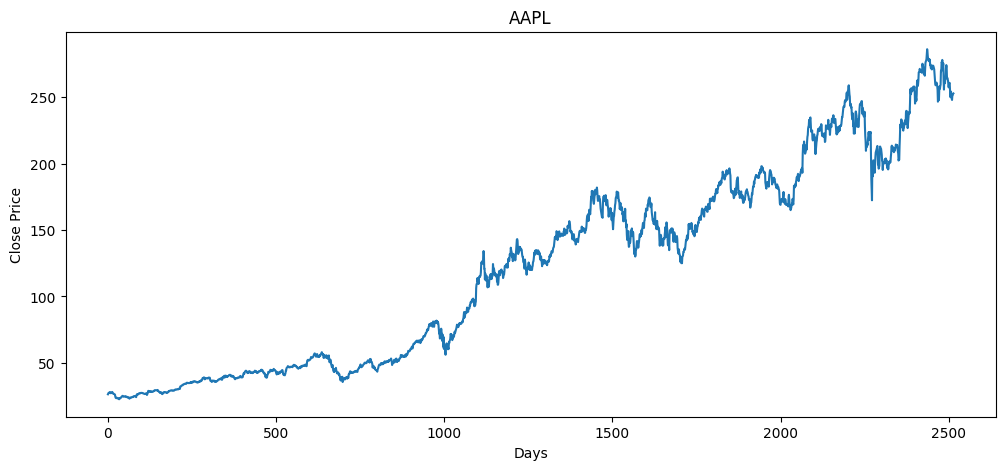

In [16]:
plt.figure(figsize=(12, 5));
plt.plot(df.Close);
plt.title(ticker);
plt.xlabel("Days");
plt.ylabel("Close Price");

# 3. Feature Engineering

In [18]:
temp_df = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
print(sum(temp_df[:5]) / 5)

30.0


In [19]:
df1 = pd.DataFrame([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
df1

,0
0,10
1,20
2,30
3,40
4,50
5,60
6,70
7,80
8,90
9,100


In [20]:
df1['MA_5'] = df1.rolling(5).mean()
df1

,0,MA_5
0,10,NaN
1,20,NaN
2,30,NaN
3,40,NaN
4,50,30.0
5,60,40.0
6,70,50.0
7,80,60.0
8,90,70.0
9,100,80.0


### 100 Days Moving Average

In [22]:
df['MA_100'] = df.Close.rolling(100).mean()
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100
0,2016-03-28,23.823477,26.297501,26.547501,26.264999,26.5000,77645600,NaN
1,2016-03-29,24.387407,26.920000,26.947500,26.219999,26.2225,124760400,NaN
2,2016-03-30,24.813208,27.389999,27.605000,27.150000,27.1625,182404400,NaN
3,2016-03-31,24.684101,27.247499,27.475000,27.219999,27.4300,103553600,NaN
4,2016-04-01,24.910589,27.497499,27.500000,27.049999,27.1950,103496000,NaN


In [23]:
df.head(103)

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100
0,2016-03-28,23.823477,26.297501,26.547501,26.264999,26.500000,77645600,NaN
1,2016-03-29,24.387407,26.920000,26.947500,26.219999,26.222500,124760400,NaN
2,2016-03-30,24.813208,27.389999,27.605000,27.150000,27.162500,182404400,NaN
3,2016-03-31,24.684101,27.247499,27.475000,27.219999,27.430000,103553600,NaN
4,2016-04-01,24.910589,27.497499,27.500000,27.049999,27.195000,103496000,NaN
...,...,...,...,...,...,...,...,...
98,2016-08-15,25.081184,27.370001,27.385000,27.020000,27.035000,103472800,NaN
99,2016-08-16,25.058268,27.344999,27.557501,27.302500,27.407499,135177600,25.135125
100,2016-08-17,25.021622,27.305000,27.342501,27.084999,27.275000,101424000,25.145200
101,2016-08-18,24.989544,27.270000,27.400000,27.254999,27.307501,87938800,25.148700


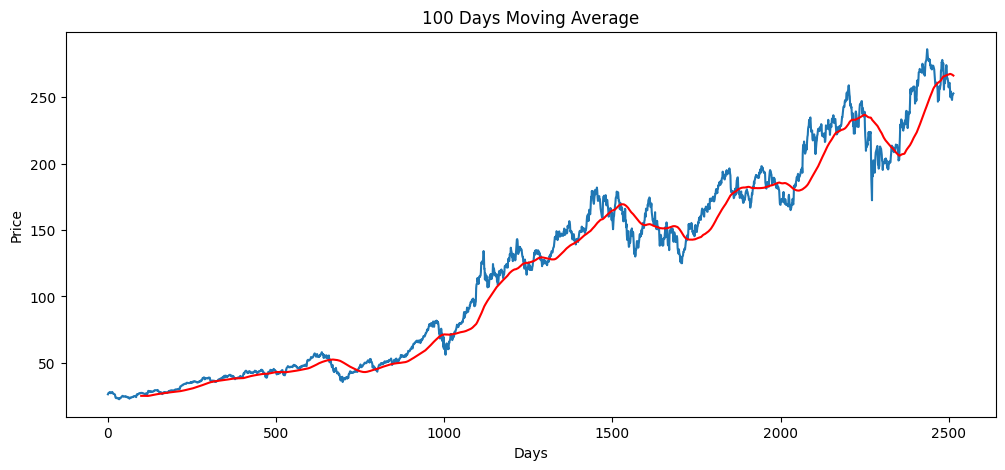

In [24]:
plt.figure(figsize=(12, 5));
plt.plot(df.Close);
plt.plot(df['MA_100'], 'r');
plt.title("100 Days Moving Average");
plt.xlabel("Days");
plt.ylabel("Price");

### 200 Days Moving Average

In [26]:
df['MA_200'] = df.Close.rolling(200).mean()
df.head(203)

,Date,Adj Close,Close,High,Low,Open,Volume,MA_100,MA_200
0,2016-03-28,23.823477,26.297501,26.547501,26.264999,26.500000,77645600,NaN,NaN
1,2016-03-29,24.387407,26.920000,26.947500,26.219999,26.222500,124760400,NaN,NaN
2,2016-03-30,24.813208,27.389999,27.605000,27.150000,27.162500,182404400,NaN,NaN
3,2016-03-31,24.684101,27.247499,27.475000,27.219999,27.430000,103553600,NaN,NaN
4,2016-04-01,24.910589,27.497499,27.500000,27.049999,27.195000,103496000,NaN,NaN
...,...,...,...,...,...,...,...,...,...
198,2017-01-06,27.151134,29.477501,29.540001,29.117500,29.195000,127007600,28.086725,NaN
199,2017-01-09,27.399826,29.747499,29.857500,29.485001,29.487499,134247600,28.110750,26.622938
200,2017-01-10,27.427452,29.777500,29.844999,29.575001,29.692499,97848400,28.135475,26.640338
201,2017-01-11,27.574823,29.937500,29.982500,29.650000,29.684999,110354400,28.162150,26.655425


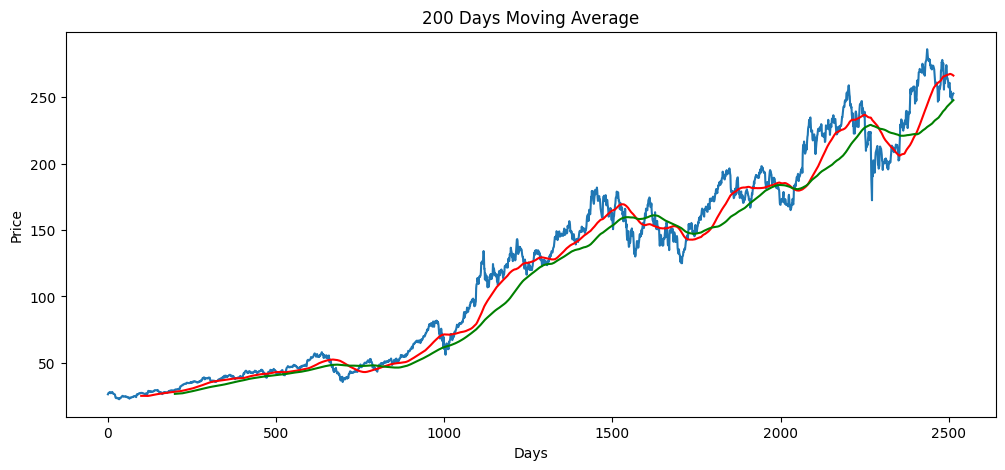

In [27]:
plt.figure(figsize=(12, 5));
plt.plot(df.Close);
plt.plot(df['MA_100'], 'r');
plt.plot(df['MA_200'], 'g');
plt.title("200 Days Moving Average");
plt.xlabel("Days");
plt.ylabel("Price");

### Calculating % Changed In Each Trading Session

In [29]:
df['Percentage Changed'] = df.Close.pct_change()
df[['Close', 'Percentage Changed']]

,Close,Percentage Changed
0,26.297501,NaN
1,26.920000,0.023671
2,27.389999,0.017459
3,27.247499,-0.005203
4,27.497499,0.009175
...,...,...
2510,247.990005,-0.003896
2511,251.490005,0.014113
2512,251.639999,0.000596
2513,252.619995,0.003894


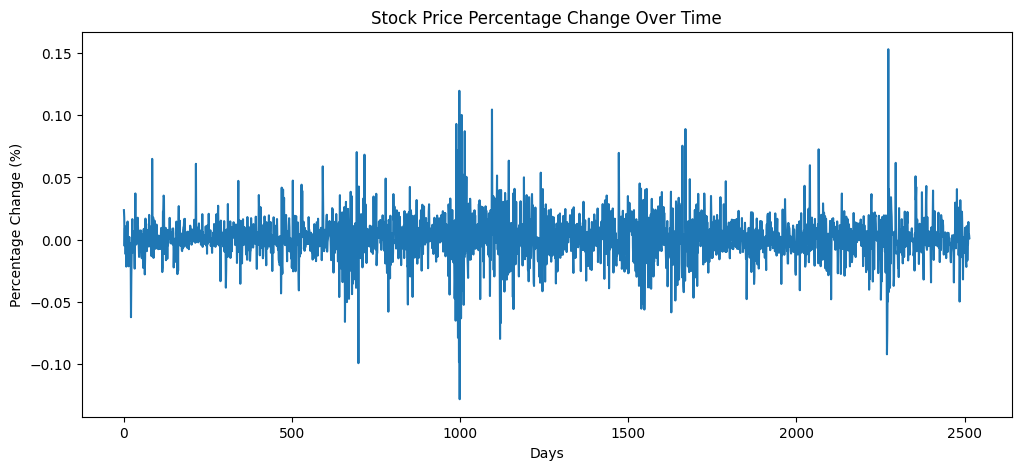

In [30]:
plt.figure(figsize=(12, 5));
plt.plot(df['Percentage Changed']);

plt.xlabel("Days");
plt.ylabel("Percentage Change (%)");
plt.title("Stock Price Percentage Change Over Time");

# 4. Data Preprocessing

In [32]:
df.shape

(2515, 10)

In [33]:
data_training = pd.DataFrame(df.Close[0:int(len(df) * 0.7)])
data_testing = pd.DataFrame(df.Close[int(len(df) * 0.7) : int(len(df))])

print(data_training)
print(data_testing)

           Close
0      26.297501
1      26.920000
2      27.389999
3      27.247499
4      27.497499
...          ...
1755  155.850006
1756  155.000000
1757  157.399994
1758  159.279999
1759  157.830002

[1760 rows x 1 columns]
           Close
1760  158.929993
1761  160.250000
1762  158.279999
1763  157.649994
1764  160.770004
...          ...
2510  247.990005
2511  251.490005
2512  251.639999
2513  252.619995
2514  252.889999

[755 rows x 1 columns]


In [34]:
data_training

,Close
0,26.297501
1,26.920000
2,27.389999
3,27.247499
4,27.497499
...,...
1755,155.850006
1756,155.000000
1757,157.399994
1758,159.279999


In [35]:
data_testing

,Close
1760,158.929993
1761,160.250000
1762,158.279999
1763,157.649994
1764,160.770004
...,...
2510,247.990005
2511,251.490005
2512,251.639999
2513,252.619995


In [36]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

In [37]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02328682],
       [0.02719148],
       [0.03013957],
       ...,
       [0.84563273],
       [0.85742514],
       [0.84832998]])

In [38]:
type(data_training_array)

numpy.ndarray

In [39]:
data_training_array.shape

(1760, 1)

# 5. Sequence Creation

In [41]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100 : i])
    y_train.append(data_training_array[i , 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [42]:
x_train

array([[[0.02328682],
        [0.02719148],
        [0.03013957],
        ...,
        [0.02797554],
        [0.03001413],
        [0.0298573 ]],

       [[0.02719148],
        [0.03013957],
        [0.02924573],
        ...,
        [0.03001413],
        [0.0298573 ],
        [0.02960641]],

       [[0.03013957],
        [0.02924573],
        [0.03081387],
        ...,
        [0.0298573 ],
        [0.02960641],
        [0.02938687]],

       ...,

       [[0.79576604],
        [0.81389369],
        [0.79513885],
        ...,
        [0.8179709 ],
        [0.83591037],
        [0.83057867]],

       [[0.81389369],
        [0.79513885],
        [0.76659876],
        ...,
        [0.83591037],
        [0.83057867],
        [0.84563273]],

       [[0.79513885],
        [0.76659876],
        [0.83522039],
        ...,
        [0.83057867],
        [0.84563273],
        [0.85742514]]])

In [43]:
x_train.ndim

3

In [44]:
y_train

array([0.02960641, 0.02938687, 0.02982594, ..., 0.84563273, 0.85742514,
       0.84832998])

In [45]:
y_train.ndim

1

In [46]:
x_train.shape

(1660, 100, 1)

In [47]:
y_train.shape

(1660,)

# 6. Model Building

In [49]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [50]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Input

In [51]:
model = Sequential()

model.add(Input(shape=(100, 1)))
model.add(LSTM(units=128, activation='tanh', return_sequences=True))
model.add(LSTM(units=64))
model.add(Dense(25))
model.add(Dense(1))

# 7. Model Training 

In [53]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 [==============================] - 24s 244ms/step - loss: 0.0191
Epoch 2/50
52/52 [==============================] - 15s 289ms/step - loss: 7.0769e-04
Epoch 3/50
52/52 [==============================] - 34s 655ms/step - loss: 6.7199e-04
Epoch 4/50
52/52 [==============================] - 13s 249ms/step - loss: 7.2467e-04
Epoch 5/50
52/52 [==============================] - 12s 229ms/step - loss: 6.5395e-04
Epoch 6/50
52/52 [==============================] - 13s 253ms/step - loss: 6.2872e-04
Epoch 7/50
52/52 [==============================] - 14s 267ms/step - loss: 6.0091e-04
Epoch 8/50
52/52 [==============================] - 12s 240ms/step - loss: 6.1061e-04
Epoch 9/50
52/52 [==============================] - 13s 243ms/step - loss: 5.7908e-04
Epoch 10/50
52/52 [==============================] - 13s 243ms/step - loss: 6.3197e-04
Epoch 11/50
52/52 [==============================] - 12s 233ms/step - loss: 5.0957e-04
Epoch 12/50
52/52 [==============================] - 14s

In [96]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 100, 128)          66560     
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 25)                1625      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 117,619
Trainable params: 117,619
Non-trainable params: 0
_________________________________________________________________


In [98]:
model.save('stock_prediction_model.keras')

# 8. Preparing Test Data

In [105]:
data_training.tail(100)

,Close
1660,144.800003
1661,155.740005
1662,153.339996
1663,150.649994
1664,145.029999
...,...
1755,155.850006
1756,155.000000
1757,157.399994
1758,159.279999


In [100]:
data_testing

,Close
1760,158.929993
1761,160.250000
1762,158.279999
1763,157.649994
1764,160.770004
...,...
2510,247.990005
2511,251.490005
2512,251.639999
2513,252.619995


In [107]:
past_100_days = data_training.tail(100)

In [109]:
past_100_days

,Close
1660,144.800003
1661,155.740005
1662,153.339996
1663,150.649994
1664,145.029999
...,...
1755,155.850006
1756,155.000000
1757,157.399994
1758,159.279999


In [111]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)
final_df

,Close
0,144.800003
1,155.740005
2,153.339996
3,150.649994
4,145.029999
...,...
850,247.990005
851,251.490005
852,251.639999
853,252.619995


In [113]:
input_data = scaler.fit_transform(final_df)
input_data

array([[1.22727590e-01],
       [1.90606240e-01],
       [1.75715075e-01],
       [1.59024610e-01],
       [1.24154628e-01],
       [8.59962012e-02],
       [8.28938869e-02],
       [8.62443446e-02],
       [8.98430405e-02],
       [6.11155806e-02],
       [1.35571122e-01],
       [1.53130232e-01],
       [1.44319671e-01],
       [1.55239782e-01],
       [1.47483997e-01],
       [1.59458979e-01],
       [1.62995568e-01],
       [1.42644394e-01],
       [1.56108427e-01],
       [1.61630637e-01],
       [1.43264895e-01],
       [1.19128894e-01],
       [1.00204759e-01],
       [1.42768513e-01],
       [1.44505802e-01],
       [1.41403488e-01],
       [1.34082071e-01],
       [1.11000846e-01],
       [9.87777206e-02],
       [1.09387582e-01],
       [1.06347375e-01],
       [1.20804170e-01],
       [1.26884680e-01],
       [1.12862254e-01],
       [7.12291552e-02],
       [5.88819105e-02],
       [4.56040095e-02],
       [4.51697347e-02],
       [6.47142764e-02],
       [4.47353653e-02],


In [115]:
input_data.shape

(855, 1)

In [119]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100 : i])
    y_test.append(input_data[i, 0])

In [121]:
x_test, y_test = np.array(x_test), np.array(y_test)

In [126]:
x_test[0].shape

(100, 1)

In [128]:
x_test

array([[[0.12272759],
        [0.19060624],
        [0.17571508],
        ...,
        [0.20090585],
        [0.21257058],
        [0.20357389]],

       [[0.19060624],
        [0.17571508],
        [0.15902461],
        ...,
        [0.21257058],
        [0.20357389],
        [0.21039893]],

       [[0.17571508],
        [0.15902461],
        [0.12415463],
        ...,
        [0.20357389],
        [0.21039893],
        [0.21858908]],

       ...,

       [[0.89334242],
        [0.89768574],
        [0.90823349],
        ...,
        [0.76900171],
        [0.76298321],
        [0.78469941]],

       [[0.89768574],
        [0.90823349],
        [0.90184273],
        ...,
        [0.76298321],
        [0.78469941],
        [0.78563007]],

       [[0.90823349],
        [0.90184273],
        [0.89365258],
        ...,
        [0.78469941],
        [0.78563007],
        [0.79171058]]])

# 9. Making Predictions

In [130]:
y_predicted = model.predict(x_test)

24/24 [==============================] - 9s 160ms/step


In [132]:
y_predicted

array([[0.2017113 ],
       [0.20442313],
       [0.2086784 ],
       [0.20744285],
       [0.20336556],
       [0.2069166 ],
       [0.21550217],
       [0.22866869],
       [0.24162644],
       [0.24829969],
       [0.24562651],
       [0.24290746],
       [0.2349796 ],
       [0.2255624 ],
       [0.21772265],
       [0.2260885 ],
       [0.23612055],
       [0.24305588],
       [0.24921325],
       [0.25547874],
       [0.25689372],
       [0.25206935],
       [0.24778473],
       [0.24164075],
       [0.23730916],
       [0.24640477],
       [0.25974151],
       [0.26920795],
       [0.2709595 ],
       [0.26662505],
       [0.25791162],
       [0.27041078],
       [0.28508073],
       [0.2902445 ],
       [0.29456604],
       [0.29730478],
       [0.29536238],
       [0.2914312 ],
       [0.28854862],
       [0.28885207],
       [0.296162  ],
       [0.30312714],
       [0.30460393],
       [0.2968086 ],
       [0.28999504],
       [0.28931433],
       [0.29718   ],
       [0.309

In [134]:
y_test

array([0.21039893, 0.21858908, 0.20636595, 0.20245701, 0.22181551,
       0.23168085, 0.24744056, 0.25532047, 0.25197001, 0.24036729,
       0.24595151, 0.22963331, 0.22200164, 0.21765842, 0.25153564,
       0.24936408, 0.2494881 , 0.25718188, 0.26437927, 0.25829866,
       0.24818518, 0.2501086 , 0.2404294 , 0.24036729, 0.26921887,
       0.27709868, 0.27654029, 0.27002541, 0.26326239, 0.25296268,
       0.30123478, 0.30080041, 0.29006643, 0.30117267, 0.30235156,
       0.29503015, 0.29192783, 0.29192783, 0.29577467, 0.3104176 ,
       0.31110011, 0.30514363, 0.28876341, 0.2905007 , 0.29763608,
       0.31277529, 0.32437801, 0.32406776, 0.34168889, 0.34702487,
       0.33852456, 0.33622888, 0.32760445, 0.34466718, 0.34708698,
       0.36464599, 0.3616678 , 0.36563876, 0.37842027, 0.37165725,
       0.37221565, 0.36570086, 0.38456289, 0.38257736, 0.37382891,
       0.39113978, 0.3985233 , 0.40063286, 0.42780916, 0.4184402 ,
       0.41142894, 0.41440714, 0.40739588, 0.39455235, 0.39126

In [136]:
y_predicted = scaler.inverse_transform(y_predicted.reshape(-1, 1)).flatten()
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

In [138]:
y_predicted

array([157.5298 , 157.96687, 158.6527 , 158.45357, 157.79642, 158.36874,
       159.75249, 161.87453, 163.96294, 165.03845, 164.60762, 164.1694 ,
       162.89166, 161.3739 , 160.11035, 161.45868, 163.07555, 164.19331,
       165.18568, 166.1955 , 166.42355, 165.64601, 164.95546, 163.96524,
       163.26712, 164.73305, 166.88254, 168.40823, 168.69054, 167.99196,
       166.58762, 168.6021 , 170.96646, 171.79869, 172.49521, 172.9366 ,
       172.62355, 171.98996, 171.52538, 171.57428, 172.75243, 173.875  ,
       174.113  , 172.85663, 171.7585 , 171.64879, 172.9165 , 174.90157,
       176.2812 , 178.074  , 179.60556, 179.78201, 179.26527, 178.15793,
       178.54819, 179.44063, 181.35057, 182.55682, 183.27734, 184.43587,
       184.73328, 184.65526, 184.0287 , 184.88408, 185.69716, 185.48781,
       186.30676, 187.63365, 188.66975, 191.14854, 192.2404 , 191.82202,
       191.35374, 190.58952, 189.15085, 187.95444, 188.18327, 189.10829,
       189.88354, 191.77011, 193.00145, 194.06586, 

In [140]:
y_test

array([158.92999268, 160.25      , 158.27999878, 157.6499939 ,
       160.77000427, 162.36000061, 164.8999939 , 166.16999817,
       165.63000488, 163.75999451, 164.66000366, 162.02999878,
       160.80000305, 160.1000061 , 165.55999756, 165.21000671,
       165.22999573, 166.47000122, 167.63000488, 166.6499939 ,
       165.02000427, 165.33000183, 163.77000427, 163.75999451,
       168.41000366, 169.67999268, 169.58999634, 168.53999329,
       167.44999695, 165.78999329, 173.57000732, 173.5       ,
       171.77000427, 173.55999756, 173.75      , 172.57000732,
       172.07000732, 172.07000732, 172.69000244, 175.05000305,
       175.16000366, 174.19999695, 171.55999756, 171.83999634,
       172.99000549, 175.42999268, 177.30000305, 177.25      ,
       180.08999634, 180.94999695, 179.58000183, 179.21000671,
       177.82000732, 180.57000732, 180.96000671, 183.78999329,
       183.30999756, 183.94999695, 186.00999451, 184.91999817,
       185.00999451, 183.96000671, 187.        , 186.67

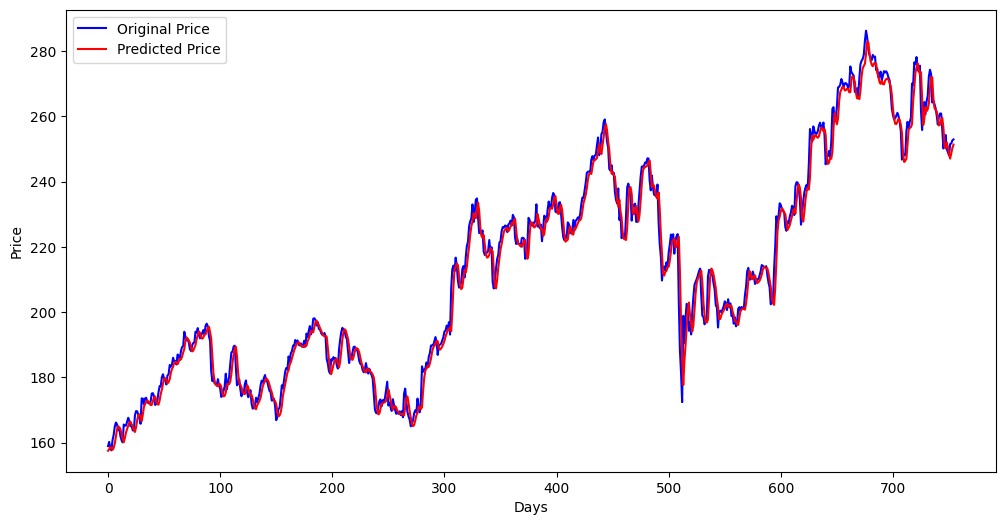

In [146]:
plt.figure(figsize=(12, 6));
plt.plot(y_test, 'b', label='Original Price');
plt.plot(y_predicted, 'r', label='Predicted Price');
plt.xlabel('Days');
plt.ylabel('Price');
plt.legend();

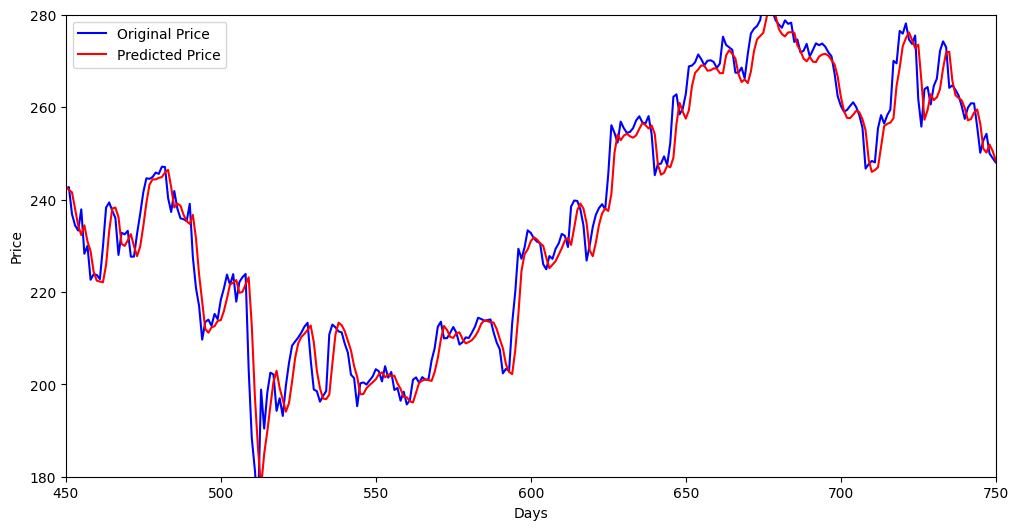

In [144]:
plt.figure(figsize=(12, 6));
plt.plot(y_test, 'b', label='Original Price');
plt.plot(y_predicted, 'r', label='Predicted Price');
plt.xlabel('Days');
plt.ylabel('Price');
plt.legend();
plt.xlim(450, 750);
plt.ylim(180, 280);

# 10. Model Evaluation

In [155]:
from sklearn.metrics import mean_squared_error, r2_score

In [151]:
mse = mean_squared_error(y_test, y_predicted)
print(f"Mean Squared Error (MSE): {mse}")

Mean Squared Error (MSE): 16.245167262335027


In [153]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse}")

Root Mean Squared Error (RMSE): 4.030529402241724


In [159]:
r2 = r2_score(y_test, y_predicted)
print(f"R-Squared:{r2}")

R-Squared:0.9848000640883388
